In [1]:
import os, sys, time, json
from pathlib import Path

# Permet d'importer le package src/ depuis ce notebook (situé dans notebooks/).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import Image, Markdown, display

from src.config import (
    CHAT_MODEL, EMBEDDING_MODEL, LLM_PROVIDER,
    COLLECTION_NAME, CHROMA_DIR, EVAL_DIR, ARTIFACTS_DIR,
    RETRIEVER_K, MAX_ITERATIONS,
)
# graph_with_memory ships an InMemorySaver so thread_id provides short-term
# memory. The bare ``graph`` (no checkpointer) is the one langgraph dev /
# Studio loads via langgraph.json (the LangGraph API manages persistence
# itself and rejects graphs with a custom checkpointer).
from src.graph import graph_with_memory as graph
from src.ingest import get_vectorstore

print(f"Provider LLM        : {LLM_PROVIDER}")
print(f"Modèle chat         : {CHAT_MODEL}")
print(f"Modèle embeddings   : {EMBEDDING_MODEL}")
print(f"Vector store Chroma : {CHROMA_DIR.name} (collection: {COLLECTION_NAME})")
print(f"K retrieval         : {RETRIEVER_K}")
print(f"Max iterations      : {MAX_ITERATIONS}")

Provider LLM        : ollama
Modèle chat         : llama3.2:latest
Modèle embeddings   : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Vector store Chroma : chroma_db (collection: tourism_morocco)
K retrieval         : 5
Max iterations      : 3


## 2. Visualisation du graphe LangGraph

Rendu Mermaid → PNG, utilisable directement dans le rapport.

Diagramme enregistré : /Users/idrissessadik/Documents/project_fin_module/artifacts/graph.png


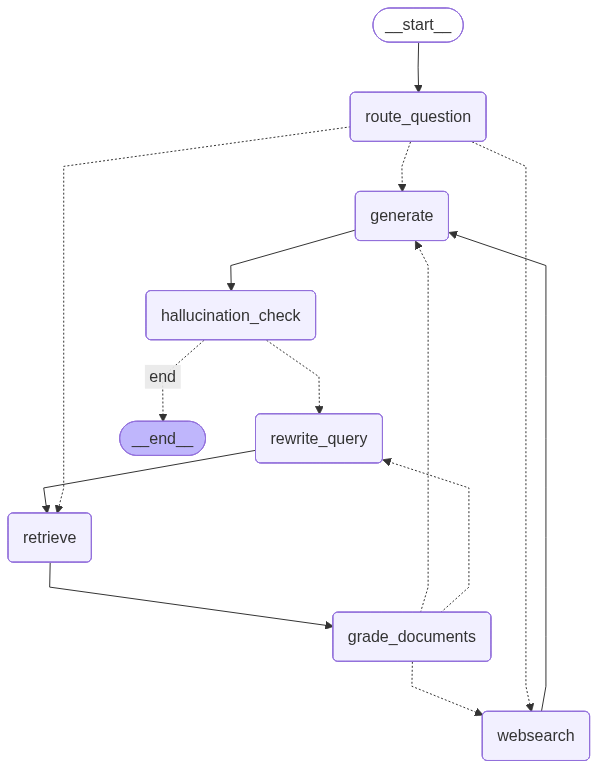

In [2]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
png_path = ARTIFACTS_DIR / "graph.png"

png_bytes = graph.get_graph().draw_mermaid_png()
png_path.write_bytes(png_bytes)
print(f"Diagramme enregistré : {png_path}")
display(Image(png_bytes))

In [3]:
# Mermaid source (utile dans le rapport)
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	route_question(route_question)
	retrieve(retrieve)
	grade_documents(grade_documents)
	rewrite_query(rewrite_query)
	websearch(websearch)
	generate(generate)
	hallucination_check(hallucination_check)
	__end__([<p>__end__</p>]):::last
	__start__ --> route_question;
	generate --> hallucination_check;
	grade_documents -.-> generate;
	grade_documents -.-> rewrite_query;
	grade_documents -.-> websearch;
	hallucination_check -. &nbsp;end&nbsp; .-> __end__;
	hallucination_check -.-> rewrite_query;
	retrieve --> grade_documents;
	rewrite_query --> retrieve;
	route_question -.-> generate;
	route_question -.-> retrieve;
	route_question -.-> websearch;
	websearch --> generate;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 3. État du corpus vectoriel

Le corpus est constitué d'environ **15 fichiers Markdown** (régions du Maroc, gastronomie, artisanat, sites UNESCO, festivals, infos pratiques) ingérés par le script `src/ingest.py`. La pipeline d'ingestion enchaîne&nbsp;:

1. **Chargement** récursif des fichiers `.md` / `.txt` / `.pdf` depuis `data/corpus/`.
2. **Découpage** avec `RecursiveCharacterTextSplitter` — taille de chunk **800 caractères**, recouvrement **120 caractères** (≈ 15&nbsp;%), séparateurs hiérarchiques `\n\n` → `\n` → `". "` → mot → caractère, ce qui préserve les frontières de paragraphes et de phrases.
3. **Embedding** avec `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` (384&nbsp;dimensions, multilingue FR/EN/AR, ~120&nbsp;Mo, exécutable sur CPU).
4. **Indexation persistante** dans **Chroma** sous le nom de collection `tourism_morocco`, stocké dans `chroma_db/`.

In [4]:
vs = get_vectorstore()
collection = vs._collection
n_chunks = collection.count()
print(f"Nombre total de chunks dans Chroma : {n_chunks}")

# Aperçu des sources indexées
sample = collection.get(limit=n_chunks, include=["metadatas"])
sources = sorted({m.get("source", "?") for m in sample["metadatas"]})
print(f"Documents sources    : {len(sources)}")
for s in sources:
    print(f"  - {s}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Nombre total de chunks dans Chroma : 207
Documents sources    : 29
  - /Users/idrissessadik/Documents/project_fin_module/data/corpus/README.md
  - /Users/idrissessadik/Documents/project_fin_module/data/corpus/bangkok.md
  - /Users/idrissessadik/Documents/project_fin_module/data/corpus/barcelone.md
  - /Users/idrissessadik/Documents/project_fin_module/data/corpus/climat_saisons.md
  - /Users/idrissessadik/Documents/project_fin_module/data/corpus/cuisine_monde.md
  - /Users/idrissessadik/Documents/project_fin_module/data/corpus/culture/artisanat.md
  - /Users/idrissessadik/Documents/project_fin_module/data/corpus/culture/festivals.md
  - /Users/idrissessadik/Documents/project_fin_module/data/corpus/culture/gastronomie.md
  - /Users/idrissessadik/Documents/project_fin_module/data/corpus/culture/unesco-sites.md
  - /Users/idrissessadik/Documents/project_fin_module/data/corpus/dubai.md
  - /Users/idrissessadik/Documents/project_fin_module/data/corpus/infos_pratiques.md
  - /Users/idrissessa

## 4. Démonstration interactive — Requête SIMPLE

On exécute une question factuelle, on capture le **chemin du graphe** et les **sources retrouvées**.

In [5]:
def show_run(question: str, thread_id: str = "demo"):
    """Invoque le graphe et affiche un résumé lisible (réponse, latence, sources, itérations)."""
    t0 = time.perf_counter()
    state = graph.invoke(
        {"question": question},
        config={"configurable": {"thread_id": thread_id}},
    )
    dt = time.perf_counter() - t0

    docs = state.get("documents") or []
    sources = sorted({d.metadata.get("source", "?") for d in docs})
    display(Markdown(f"**Question :** {question}"))
    display(Markdown(f"**Réponse :**\n\n{state.get('generation','(vide)')}"))
    print()
    print(f"Latence              : {dt:.2f} s")
    print(f"Itérations rewrite   : {state.get('iterations', 0)}")
    print(f"Web search utilisé   : {state.get('web_search_used', False)}")
    print(f"Retries hallucination: {state.get('halluc_retries', 0)}")
    print(f"Docs récupérés       : {len(docs)}")
    print(f"Sources              : {', '.join(sources) if sources else '(aucune)'}")
    return state, dt

state_simple, _ = show_run("Quel est le surnom de Marrakech ?")

**Question :** Quel est le surnom de Marrakech ?

**Réponse :**

Le surnom de Marrakech est "la Ville Rouge" [source]. Cette appellation est due à la couleur ocre des remparts de la médina, qui sont construits en pisé [1].


Latence              : 14.76 s
Itérations rewrite   : 0
Web search utilisé   : False
Retries hallucination: 0
Docs récupérés       : 2
Sources              : /Users/idrissessadik/Documents/project_fin_module/data/corpus/culture/unesco-sites.md, /Users/idrissessadik/Documents/project_fin_module/data/corpus/regions/marrakech.md


## 5. Démonstration interactive — Requête COMPLEXE

Une question qui exige une synthèse à partir de plusieurs documents (gastronomie, festivals, régions).

In [15]:
state_complex, _ = show_run(
    "Compare l'expérience touristique à Fès et à Marrakech pour un visiteur "
    "intéressé par l'artisanat traditionnel et le patrimoine UNESCO."
)

KeyboardInterrupt: 

## 6. Évaluation systématique — 20 questions (10 simples + 10 complexes)

On lit `eval/questions.json` et on exécute chaque question à travers le graphe. Pour chacune on capture :

- la réponse générée  
- la latence (`time.perf_counter`)  
- le nombre d'itérations  
- les sources retrouvées (pour la pertinence du retrieval)  
- si la fallback web a été utilisée  
- le nombre de retries hallucination

In [7]:
questions_path = EVAL_DIR / "questions.json"
items = json.loads(questions_path.read_text(encoding="utf-8"))
print(f"Chargé {len(items)} questions depuis {questions_path}")
print(f"  - simples : {sum(1 for q in items if q.get('type')=='simple')}")
print(f"  - complexes: {sum(1 for q in items if q.get('type')=='complex')}")

Chargé 20 questions depuis /Users/idrissessadik/Documents/project_fin_module/eval/questions.json
  - simples : 10
  - complexes: 10


In [8]:
rows = []
for i, item in enumerate(items, start=1):
    q = item["question"]
    qtype = item.get("type", "?")
    print(f"[{i:02d}/{len(items)}] ({qtype}) {q[:90]}")
    t0 = time.perf_counter()
    try:
        state = graph.invoke(
            {"question": q},
            config={"configurable": {"thread_id": f"eval-{i}"}},
        )
        dt = time.perf_counter() - t0
        docs = state.get("documents") or []
        rows.append({
            "id": item.get("id", f"Q{i:02d}"),
            "type": qtype,
            "question": q,
            "reference": item.get("reference", ""),
            "answer": state.get("generation", ""),
            "latency_s": round(dt, 2),
            "iterations": state.get("iterations", 0),
            "web_search_used": state.get("web_search_used", False),
            "halluc_retries": state.get("halluc_retries", 0),
            "n_docs": len(docs),
            "sources": ";".join(sorted({d.metadata.get("source", "?") for d in docs})),
            "error": "",
        })
    except Exception as e:
        dt = time.perf_counter() - t0
        print(f"  [!] Erreur : {e}")
        rows.append({
            "id": item.get("id", f"Q{i:02d}"),
            "type": qtype,
            "question": q,
            "reference": item.get("reference", ""),
            "answer": "",
            "latency_s": round(dt, 2),
            "iterations": 0,
            "web_search_used": False,
            "halluc_retries": 0,
            "n_docs": 0,
            "sources": "",
            "error": str(e),
        })

df = pd.DataFrame(rows)
out_dir = EVAL_DIR / "results"
out_dir.mkdir(parents=True, exist_ok=True)
csv_path = out_dir / "results.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"\n[done] {len(df)} résultats écrits dans {csv_path}")

[01/20] (simple) Quel est le surnom de la ville de Marrakech ?
[02/20] (simple) En quelle année l'université Al Quaraouiyine de Fès a-t-elle été fondée et par qui ?
[03/20] (simple) Quelle est la hauteur du minaret de la mosquée Hassan II à Casablanca ?
[04/20] (simple) Combien de sites marocains sont inscrits au patrimoine mondial de l'UNESCO ?
[05/20] (simple) Quel est le point culminant du Maroc et quelle est son altitude ?
[06/20] (simple) Qui a créé le jardin Majorelle à Marrakech et en quelle décennie ?
[07/20] (simple) Quel festival musical se tient à Essaouira chaque mois de juin ?
[08/20] (simple) Quelle est la monnaie officielle du Maroc ?
[09/20] (simple) Combien de temps les citoyens de l'Union Européenne peuvent-ils rester au Maroc sans visa 
[10/20] (simple) Quelle est la couleur dominante des maisons de Chefchaouen et pourquoi ?
[11/20] (complex) Compare l'expérience touristique à Fès et à Marrakech pour un visiteur intéressé par l'art
[12/20] (complex) Quelles sont les 

## 7. Analyse des résultats

Trois axes d'analyse imposés par la grille de notation :

1. **Qualité des réponses** (rubrique "Expérimentation et Simulation")  
2. **Temps de réponse**  
3. **Pertinence du retrieval** (sources réellement utilisées)

In [9]:
# Tableau condensé pour le rapport
display(df[["id", "type", "question", "latency_s", "n_docs", "iterations", "web_search_used", "halluc_retries"]])

,id,type,question,latency_s,n_docs,iterations,web_search_used,halluc_retries
0,S01,simple,Quel est le surnom de la ville de Marrakech ?,8.20,2,0,False,0
1,S02,simple,En quelle année l'université Al Quaraouiyine d...,16.79,1,1,False,2
2,S03,simple,Quelle est la hauteur du minaret de la mosquée...,16.70,1,1,False,2
3,S04,simple,Combien de sites marocains sont inscrits au pa...,31.55,4,1,False,2
4,S05,simple,Quel est le point culminant du Maroc et quelle...,26.38,1,1,False,1
5,S06,simple,Qui a créé le jardin Majorelle à Marrakech et ...,19.73,1,1,False,2
6,S07,simple,Quel festival musical se tient à Essaouira cha...,27.33,3,1,True,1
7,S08,simple,Quelle est la monnaie officielle du Maroc ?,14.29,1,0,False,0
8,S09,simple,Combien de temps les citoyens de l'Union Europ...,11.56,1,0,False,0
9,S10,simple,Quelle est la couleur dominante des maisons de...,22.94,2,0,False,0


In [10]:
# Résumé par type de question
summary = (
    df.groupby("type")
      .agg(
          count=("question", "count"),
          avg_latency_s=("latency_s", "mean"),
          median_latency_s=("latency_s", "median"),
          avg_iters=("iterations", "mean"),
          web_search_rate=("web_search_used", "mean"),
          avg_docs=("n_docs", "mean"),
          avg_halluc_retries=("halluc_retries", "mean"),
      )
      .round(2)
)
display(summary)
summary.to_csv(out_dir / "summary_by_type.csv")

,count,avg_latency_s,median_latency_s,avg_iters,web_search_rate,avg_docs,avg_halluc_retries
type,,,,,,,
complex,10,39.33,35.16,0.5,0.0,2.4,0.6
simple,10,19.55,18.26,0.6,0.1,1.7,1.0


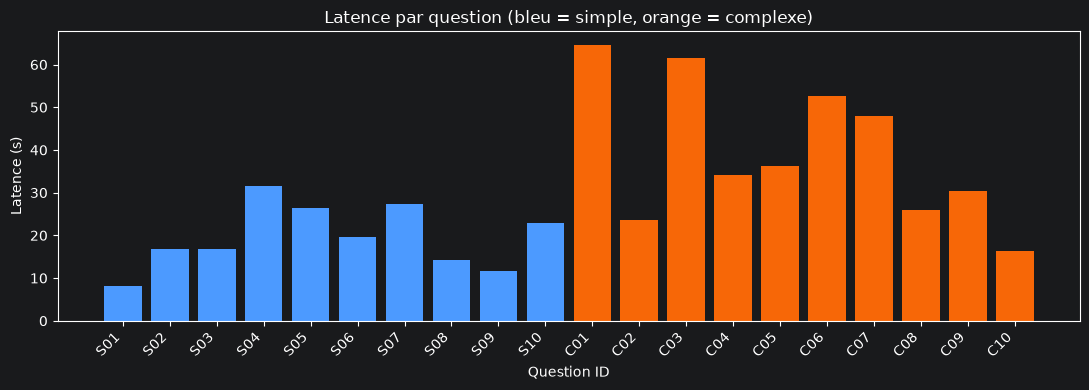

In [11]:
# Graphique latence par question (simple vs complexe)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
colors = df["type"].map({"simple": "#4C9AFF", "complex": "#F76707"})
ax.bar(df["id"], df["latency_s"], color=colors)
ax.set_xlabel("Question ID")
ax.set_ylabel("Latence (s)")
ax.set_title("Latence par question (bleu = simple, orange = complexe)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(out_dir / "latency_per_question.png", dpi=120)
plt.show()

In [12]:
# Pertinence du retrieval : fréquence des sources sollicitées sur l'ensemble des questions
from collections import Counter

src_counter: Counter[str] = Counter()
for s in df["sources"].fillna(""):
    for x in (s.split(";") if s else []):
        if x:
            src_counter[x] += 1

src_df = (
    pd.DataFrame(src_counter.items(), columns=["source", "n_questions"])
      .sort_values("n_questions", ascending=False)
      .reset_index(drop=True)
)
display(src_df)
src_df.to_csv(out_dir / "source_frequency.csv", index=False)

,source,n_questions
0,/Users/idrissessadik/Documents/project_fin_mod...,4
1,/Users/idrissessadik/Documents/project_fin_mod...,4
2,/Users/idrissessadik/Documents/project_fin_mod...,4
3,/Users/idrissessadik/Documents/project_fin_mod...,3
4,/Users/idrissessadik/Documents/project_fin_mod...,3
5,/Users/idrissessadik/Documents/project_fin_mod...,3
6,/Users/idrissessadik/Documents/project_fin_mod...,2
7,/Users/idrissessadik/Documents/project_fin_mod...,2
8,/Users/idrissessadik/Documents/project_fin_mod...,2
9,/Users/idrissessadik/Documents/project_fin_mod...,2


## 8. Inspection détaillée d'une question complexe

Utile pour la **démo vidéo** : montrer comment le système synthétise plusieurs sources.

In [13]:
# Prendre une question complexe au hasard et afficher la réponse formatée
complex_rows = df[(df["type"] == "complex") & (df["error"] == "")]
if not complex_rows.empty:
    row = complex_rows.iloc[0]
    display(Markdown(f"### {row['id']} — {row['question']}"))
    display(Markdown(f"**Réponse générée :**\n\n{row['answer']}"))
    display(Markdown(f"**Sources utilisées :** {row['sources']}"))
    display(Markdown(f"**Latence :** {row['latency_s']} s — **Itérations :** {row['iterations']}"))
    display(Markdown(f"**Réponse de référence :**\n\n_{row['reference']}_"))

### C01 — Compare l'expérience touristique à Fès et à Marrakech pour un visiteur intéressé par l'artisanat traditionnel et le patrimoine UNESCO. Quelles différences notables entre les deux villes ?

**Réponse générée :**

Pour comparer l'expérience touristique à Fès et à Marrakech pour un visiteur intéressé par l'artisanat traditionnel et le patrimoine UNESCO, voici les différences notables entre les deux villes :

**Fès**

* La médina de Fès est inscrite au patrimoine mondial de l'UNESCO depuis 1985 [4].
* L'artisanat traditionnel est très développé et varié, avec des spécialités telles que la tissage, le cuir, les bijoux, etc.
* Les souks sont organisés par corps de métier, tels que le souk des teinturiers, du cuir et des épices [5].
* La ville est connue pour son architecture historique, notamment l'Al-Attarine Madrasa et la Kasbah.
* L'expérience touristique à Fès est plus intime et authentique que celle de Marrakech.

**Marrakech**

* La médina de Marrakech est également inscrite au patrimoine mondial de l'UNESCO depuis 1985 [4].
* L'artisanat traditionnel est très développé, mais avec une plus grande variété et une plus grande visibilité que à Fès.
* Les souks sont organisés par corps de métier, tels que le souk des teinturiers, du cuir et des épices [5].
* La ville est connue pour son spectacle nocturne, notamment la place Jemaa el-Fna, qui est l'un des plus grands marchés traditionnels du monde arabe.
* L'expérience touristique à Marrakech est plus animée et plus touristique que celle de Fès.

En résumé, les deux villes offrent une expérience unique et authentique pour les visiteurs intéressés par l'artisanat traditionnel et le patrimoine UNESCO. Cependant, Fès offre une expérience plus intime et authentique, tandis que Marrakech propose une expérience plus animée et plus touristique.

Sources :

[4] (source: /Users/idrissessadik/Documents/project_fin_module/data/corpus/artisanat.md)
[5] (source: /Users/idrissessadik/Documents/project_fin_module/data/corpus/regions/marrakech.md)

**Sources utilisées :** /Users/idrissessadik/Documents/project_fin_module/data/corpus/README.md;/Users/idrissessadik/Documents/project_fin_module/data/corpus/culture/artisanat.md;/Users/idrissessadik/Documents/project_fin_module/data/corpus/regions/agadir.md;/Users/idrissessadik/Documents/project_fin_module/data/corpus/regions/marrakech.md

**Latence :** 64.55 s — **Itérations :** 1

**Réponse de référence :**

_Les deux médinas sont inscrites à l'UNESCO (Fès en 1981, Marrakech en 1985) et sont d'anciennes capitales impériales. Fès est considérée comme la capitale spirituelle et artisanale (cuir des tanneries Chouara, poterie bleue, zellige, dinanderie) avec une médina labyrinthique de 9 500 ruelles et une atmosphère plus authentique et conservatrice. Marrakech est plus touristique, avec la place Jemaa el-Fna et des souks plus grands mais aussi plus commerciaux ; ses spécialités artisanales incluent la maroquinerie (matière première venant de Fès), les lanternes en métal, les tapis Beni Ourain et les babouches. Fès convient mieux pour l'authenticité et l'apprentissage des techniques traditionnelles, Marrakech pour l'ambiance festive et le shopping varié._

## 9. Conclusion et pistes d'amélioration

Points qui peuvent être discutés dans le rapport :

- **Architecture CRAG** : la boucle `grade → rewrite → retrieve` améliore la pertinence sur les questions où la première recherche échoue (à voir dans la colonne `iterations`).
- **Hallucination-check** : un node terminal vérifie que la réponse est ancrée dans le contexte retrouvé ; sinon il relance une régénération (capée à 2 retries).
- **Memory** : `InMemorySaver` checkpointer + `thread_id` permettent une mémoire conversationnelle dans Studio.
- **Limites du modèle local (llama3.2)** : plus petit que les modèles hostés, peut manquer de finesse sur les questions complexes (synthèse, comparaisons multi-documents).
- **Améliorations possibles** : re-ranker BGE, embeddings multilingues plus gros (BGE-M3), pipeline d'évaluation LLM-as-judge, support multi-tour de conversation (chat history dans le state).

Tous les artefacts générés (PNG du graphe, CSV des résultats, graphiques) sont prêts pour le rapport PDF et la vidéo de démonstration.